## GPT architecture

In [129]:
import torch 
import torch.nn as nn

In [130]:
import sys
import os

sys.path.append(os.path.abspath(".."))

#### Configuration details for GPT -2 Module include

In [131]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_emb_rate" : 0.1,
    "drop_att_rate" : 0.1,
    "drop_shortcut_rate" : 0.1,
    "qkv_bias" : False
}

In [132]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x
    
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps = 1e-5):
        super().__init__()

    def forward(self,x):
        return x

In [133]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_emb_rate"])

        # Placeholder for Transformer Block
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) 
              for _ in range(cfg["n_layers"])]
        )

        # placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias = False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        print(batch_size, seq_len)
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device = in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


#### Tokenize a batch consisting of two text inputs for the GPT model using thr tiktoken tokenizer

In [134]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch =[]
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
print(batch)
batch = torch.stack(batch, dim = 0)
print(batch)


[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [135]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("output shape:", logits.shape)
print(logits)

2 4
output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### Layer Normalizations

In [136]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
print("batch example",batch_example )

layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)


batch example tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [137]:
mean = out.mean(dim =-1, keepdim=True)
var = out.var(dim =-1, keepdim= True)
print("Mean \n", mean)
print("variance \n", var)

Mean 
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
variance 
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [138]:
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim= True)
var = out_norm.var(dim =1, keepdim = True)
print("Normalized layer outputs: \n", out_norm)
print("Mean:\n" , mean)
print("Variance : \n", var)

Normalized layer outputs: 
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance : 
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [139]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n" , mean)
print("Variance : \n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance : 
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [140]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean = x.mean(dim =-1, keepdim= True)
        var = x.var(dim =-1, keepdim = True, unbiased = False)
        norm_x = (x-mean)/ torch.sqrt(var+ self.eps)
        return self.scale * norm_x + self.shift
    

In [141]:
ln = LayerNorm(emb_dim = 5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased = False)
print("Mean:\n" , mean)
print("Variance : \n", var)


Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance : 
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Implementing GELU (Guassian Error Linear unit)

In [142]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self,x):
        return 0.5 * x * (1+ torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x,3))
        ))

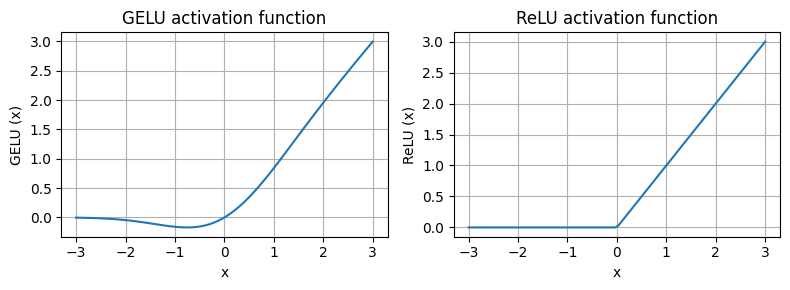

In [143]:
import matplotlib.pyplot as plt
gelu , relu = GELU(), nn. ReLU()

x = torch.linspace(-3 , 3, 100)
y_gelu, y_relu = gelu(x) , relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} (x)")
    plt.grid(True)
plt.tight_layout()
plt.show()




## feedForward neural network

In [144]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn. Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    
    def forward(self, x):
        return self.layers(x)


In [145]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [146]:
class ExampleNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            # print(f" x value for {layer} ",x)

            # print(f"Layer output for {layer}",layer_output)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
            print(f"total x value for {layer} ",x)
        return x

In [147]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleNeuralNetwork(layer_sizes, use_shortcut=False)

In [148]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()

    for name , param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [149]:
print_gradients(model_without_shortcut, sample_input)

total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[ 0.1948, -0.1414,  0.0909]], grad_fn=<MulBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[0.0219, 0.1376, 0.3824]], grad_fn=<MulBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[0.0895, 0.2220, 0.0362]], grad_fn=<MulBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[-0.0361, -0.0550,  0.1197]], grad_fn=<MulBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): GELU()
)  tensor([[0.0610]], grad_fn=<MulBackward0>)
layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weigh

In [150]:

torch.manual_seed(123)
model_with_shortcut = ExampleNeuralNetwork(layer_sizes, use_shortcut=True)

In [151]:
print_gradients(model_with_shortcut, sample_input)

total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[ 1.1948, -0.1414, -0.9091]], grad_fn=<AddBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[ 1.0989, -0.2445, -0.9104]], grad_fn=<AddBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[ 1.1771,  0.9354, -0.8146]], grad_fn=<AddBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)  tensor([[ 1.0433,  0.9930, -0.3997]], grad_fn=<AddBackward0>)
total x value for Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): GELU()
)  tensor([[0.7669]], grad_fn=<MulBackward0>)
layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight

In [152]:
import sys
print(sys.path)

['/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/opt/homebrew/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/kavyakonisa/Desktop/AgenticAI/LLM_SCRATCH/FirstLLM/.venv/lib/python3.11/site-packages', '/Users/kavyakonisa/Desktop/AgenticAI/LLM_SCRATCH/FirstLLM/Build-a-LLM', '/Users/kavyakonisa/Desktop/AgenticAI/LLM_SCRATCH/FirstLLM/Build-a-LLM', '/Users/kavyakonisa/Desktop/AgenticAI/LLM_SCRATCH/FirstLLM/Build-a-LLM']


#### Connection attention and linear layers in a transformer block

In [153]:
# from attention_mechanisms.multi_head_attention import MultiHeadAttention


In [154]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_in,d_out, context_length, dropout, num_heads, qkv_bias = False):
        super().__init__()
        assert(d_out % num_heads == 0), "d_out must be divisible by num_heads"
        

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Dimension of each head

        self. W_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self. W_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self. W_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # Output projection layer
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length), diagonal = 1)
        )

    def forward(self,x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x) # shape ==> [b, num_tokens,d_out]
        keys = self.W_key(x)
        values = self.W_value(x)

        # Reshape for multi-head attention
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) # shape ==> [b, num_tokens, num_heads , head_dim] ... d_out = num_heads * head_dim 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.transpose(1,2) # shape ==> [b, num_heads ,num_tokens, head_dim]
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # calculating attention scores and weights

        attention_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attention_scores.masked_fill_(mask_bool, -torch.inf)

        attention_weights = torch.softmax(attention_scores / self.head_dim**0.5, dim = -1)
        attention_weights = self.dropout(attention_weights)
        context_vector = (attention_weights @ values).transpose(1,2) # shape ==> [b, num_tokens, num_heads, head_dim]
        context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out) # shape ==> [b, num_tokens, d_out]

        context_vector = self.out_proj(context_vector)

        return context_vector

In [155]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length= cfg["context_length"],
            num_heads = cfg["n_heads"],
            dropout= cfg["drop_att_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_shortcut_rate"])

    def forward(self,x):
        shortcut =x
        x= self.norm1(x)
        x= self.att(x)
        x= self.drop_shortcut(x)
        x = x+ shortcut

        shortcut =x
        x= self.norm2(x)
        x= self.ff(x)
        x= self.drop_shortcut(x)
        x = x + shortcut
        
        return x


In [156]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input Shape:" , x.shape)
print("Output Shape:" , output.shape)

Input Shape: torch.Size([2, 4, 768])
Output Shape: torch.Size([2, 4, 768])


### GPT MODEL Architecture

In [168]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_emb_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [169]:
torch.manual_seed(123)
model_small = GPTModel(GPT_CONFIG_124M)

out = model_small(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [170]:
total_params_small = sum(p.numel() for p in model_small.parameters())
print(f"Total number of parameters: {total_params_small:,}")

Total number of parameters: 163,009,536


In [171]:
for name, param in model_small.named_parameters():
    print(name, param.shape, param.numel())

tok_emb.weight torch.Size([50257, 768]) 38597376
pos_emb.weight torch.Size([1024, 768]) 786432
trf_blocks.0.att.W_query.weight torch.Size([768, 768]) 589824
trf_blocks.0.att.W_key.weight torch.Size([768, 768]) 589824
trf_blocks.0.att.W_value.weight torch.Size([768, 768]) 589824
trf_blocks.0.att.out_proj.weight torch.Size([768, 768]) 589824
trf_blocks.0.att.out_proj.bias torch.Size([768]) 768
trf_blocks.0.ff.layers.0.weight torch.Size([3072, 768]) 2359296
trf_blocks.0.ff.layers.0.bias torch.Size([3072]) 3072
trf_blocks.0.ff.layers.2.weight torch.Size([768, 3072]) 2359296
trf_blocks.0.ff.layers.2.bias torch.Size([768]) 768
trf_blocks.0.norm1.scale torch.Size([768]) 768
trf_blocks.0.norm1.shift torch.Size([768]) 768
trf_blocks.0.norm2.scale torch.Size([768]) 768
trf_blocks.0.norm2.shift torch.Size([768]) 768
trf_blocks.1.att.W_query.weight torch.Size([768, 768]) 589824
trf_blocks.1.att.W_key.weight torch.Size([768, 768]) 589824
trf_blocks.1.att.W_value.weight torch.Size([768, 768]) 589824

tok_emb.weight torch.Size([50527, 768]) 38804736
out_head.weight torch.Size([50527, 768]) 38804736


In [172]:
print("Token embedding layer shape", model_small.tok_emb.weight.shape)
print("Output layer shape", model_small.out_head.weight.shape)

Token embedding layer shape torch.Size([50257, 768])
Output layer shape torch.Size([50257, 768])


In [162]:
total_params_gpt2 = (
    total_params_small - sum(p.numel() for p in model_small.out_head.parameters())
)
print(f"Total number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Total number of trainable parameters considering weight tying: 124,412,160


In [173]:
total_params_trf_ff = sum(
    p.numel()
    for block in model_small.trf_blocks
    for p in block.ff.parameters()
)
print(f"Total number of trainable parametersin ff: {total_params_trf_ff:,}")

Total number of trainable parametersin ff: 56,669,184


In [174]:
total_params_trf_att = sum(
    p.numel()
    for block in model_small.trf_blocks
    for p in block.att.parameters()
)
print(f"Total number of trainable parameters in mha: {total_params_trf_att:,}")

Total number of trainable parameters in mha: 28,320,768


In [175]:
total_size_bytes = total_params_small*4
total_size_mb = total_size_bytes/(1024 * 1024)
print(f"Total size of the model:{total_size_mb:.3f} MB")

Total size of the model:621.832 MB


## GPT2  Medium

In [176]:
GPT_CONFIG_Medium = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim" : 1024,
    "n_heads" : 16,
    "n_layers" : 24,
    "drop_emb_rate" : 0.1,
    "drop_att_rate" : 0.1,
    "drop_shortcut_rate" : 0.1,
    "qkv_bias" : False
}

In [177]:
torch.manual_seed(123)
model_medium = GPTModel(GPT_CONFIG_Medium)

out = model_medium(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.5553,  0.4949,  0.3092,  ..., -0.2539, -0.3032,  0.2971],
         [ 0.3024, -0.0328, -0.5984,  ..., -0.6252, -0.5445, -0.9409],
         [ 0.4388,  0.3456, -0.2936,  ...,  0.5144,  0.0907,  0.0242],
         [ 0.1325,  0.6145, -0.8940,  ...,  0.3889,  0.0279, -0.5072]],

        [[ 1.0220,  0.3779,  0.8361,  ...,  0.1372, -0.2403,  0.8152],
         [ 0.0192,  0.3544, -0.5428,  ..., -0.0214,  0.0261, -0.4027],
         [ 0.2641,  0.1448, -0.3102,  ..., -0.0764, -0.4402,  0.2604],
         [ 0.6284,  1.2054, -0.6994,  ...,  0.0841, -0.3732, -0.1643]]],
       grad_fn=<UnsafeViewBackward0>)


In [179]:
total_params_medium = sum(p.numel() for p in model_medium.parameters())
print(f"Total number of parameters: {total_params_medium:,}")

Total number of parameters: 406,212,608


## GPT2  Large

In [180]:
GPT_CONFIG_Large = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim" : 1280,
    "n_heads" : 20,
    "n_layers" : 36,
    "drop_emb_rate" : 0.1,
    "drop_att_rate" : 0.1,
    "drop_shortcut_rate" : 0.1,
    "qkv_bias" : False
}

In [181]:
torch.manual_seed(123)
model_large = GPTModel(GPT_CONFIG_Large)

out = model_large(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1292, -0.3847,  0.2248,  ...,  0.5369,  0.3691, -0.7619],
         [ 0.4239,  0.2338, -1.0530,  ..., -0.0855, -0.6005, -0.4725],
         [ 0.2074, -0.6801, -0.0454,  ..., -1.2456, -0.8294, -0.0187],
         [ 0.4618, -0.2833, -0.4043,  ...,  0.0392, -0.5204, -0.2321]],

        [[-0.6438,  0.1008,  0.2805,  ...,  0.5632,  0.7455, -0.3469],
         [ 0.5257, -0.0004, -0.1389,  ..., -0.3714,  0.3727,  0.1004],
         [ 0.3873, -0.7259, -0.1061,  ..., -1.1120, -0.4745,  0.2956],
         [ 0.2372, -0.0430,  0.1782,  ..., -0.4974, -0.2305,  0.2401]]],
       grad_fn=<UnsafeViewBackward0>)


In [182]:
total_params_large = sum(p.numel() for p in model_large.parameters())
print(f"Total number of parameters: {total_params_large:,}")

Total number of parameters: 838,220,800


## GPT2  XL

In [183]:
GPT_CONFIG_XL = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim" : 1600,
    "n_heads" : 25,
    "n_layers" : 48,
    "drop_emb_rate" : 0.1,
    "drop_att_rate" : 0.1,
    "drop_shortcut_rate" : 0.1,
    "qkv_bias" : False
}

In [184]:
torch.manual_seed(123)
model_XL= GPTModel(GPT_CONFIG_XL)

out = model_XL(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1291,  0.3885,  0.1057,  ...,  0.0180,  0.2309, -0.3901],
         [-0.2870, -0.0278, -0.3349,  ..., -0.0724,  0.1030, -0.3322],
         [-0.6001, -0.2720,  0.3672,  ...,  0.0804,  0.6928,  0.0880],
         [-1.3517, -0.3163,  0.2312,  ...,  0.3396, -0.0351,  0.3853]],

        [[-0.1893,  0.3246, -0.1917,  ..., -0.2170,  0.2229, -0.6889],
         [ 0.0024, -0.1743, -0.2006,  ...,  0.0684, -0.9490, -0.8778],
         [-0.0397,  0.0353,  0.2041,  ..., -0.3985,  0.1638, -0.2869],
         [-0.7979,  0.2167, -0.0873,  ...,  0.9055, -0.4025, -0.0753]]],
       grad_fn=<UnsafeViewBackward0>)


In [185]:
total_params_XL = sum(p.numel() for p in model_XL.parameters())
print(f"Total number of parameters: {total_params_XL:,}")

Total number of parameters: 1,637,792,000


### Generating Text

In [186]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:,-1,:]
        probas = torch.softmax(logits, dim =-1)
        idx_next = torch.argmax(probas, dim =-1, keepdim=True)
        idx = torch.cat((idx, idx_next),dim =1)
    return idx

In [187]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("Encoded tensor shape", encoded_tensor.shape)
print("Encoded tensor ", encoded_tensor)


encoded [15496, 11, 314, 716]
Encoded tensor shape torch.Size([1, 4])
Encoded tensor  tensor([[15496,    11,   314,   716]])


In [188]:
model_small.eval()
out = generate_text_simple(model= model_small,
                           idx = encoded_tensor,
                           max_new_tokens= 6,
                           context_size= GPT_CONFIG_124M["context_length"]
                           )
print("output: ", out)
print("Output length: ", len(out[0]))


output:  tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length:  10


In [189]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
